In [1]:
# -*- coding: utf-8 -*-
"""
# 🔬 Diabetic Retinopathy Detection — EyePACS Dataset
### EfficientNet-B4 | 13-Stage Preprocessing | Kaggle Notebook (GPU)

This notebook runs the full DR detection pipeline:
1. Setup & verify GPU
2. Dataset is directly available (no download needed!)
3. Explore class distribution
4. Run 13-stage preprocessing pipeline
5. Train EfficientNet-B4 with class-balanced strategy
6. Evaluate with confusion matrix & classification report

**How to run on Kaggle:**
1. Go to kaggle.com/c/diabetic-retinopathy-detection → Code → New Notebook
2. In the notebook, click + Add Data → Competition Data → select “Diabetic Retinopathy Detection”
3. Go to Settings → Accelerator → GPU P100
4. Paste this script and run all cells
"""

'\n# 🔬 Diabetic Retinopathy Detection — EyePACS Dataset\n### EfficientNet-B4 | 13-Stage Preprocessing | Kaggle Notebook (GPU)\n\nThis notebook runs the full DR detection pipeline:\n1. Setup & verify GPU\n2. Dataset is directly available (no download needed!)\n3. Explore class distribution\n4. Run 13-stage preprocessing pipeline\n5. Train EfficientNet-B4 with class-balanced strategy\n6. Evaluate with confusion matrix & classification report\n\n**How to run on Kaggle:**\n1. Go to kaggle.com/c/diabetic-retinopathy-detection → Code → New Notebook\n2. In the notebook, click + Add Data → Competition Data → select “Diabetic Retinopathy Detection”\n3. Go to Settings → Accelerator → GPU P100\n4. Paste this script and run all cells\n'

In [2]:
# ============================================================================
# CELL 1: Check GPU & Install Dependencies
# ============================================================================
import os
import shutil
import torch

print(f"🔧 PyTorch version: {torch.__version__}")
print(f"🎮 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU! Go to Settings → Accelerator → GPU P100")

# Install extra deps if needed (most are pre-installed on Kaggle)
import subprocess
subprocess.run(["pip", "install", "-q", "scikit-image"], check=True)

# ── Cleanup existing corrupted cache from previous run ─────────────
if os.path.exists("/kaggle/working/tensor_cache"):
    print("🧹 Cleaning up old cache to free space...")
    shutil.rmtree("/kaggle/working/tensor_cache", ignore_errors=True)
os.makedirs("/kaggle/working/tensor_cache", exist_ok=True)

🔧 PyTorch version: 2.9.0+cu126
🎮 CUDA available: True
🎮 GPU: Tesla P100-PCIE-16GB
💾 GPU Memory: 17.1 GB
🧹 Cleaning up old cache to free space...


In [3]:
# ============================================================================
# CELL 2: Configure Paths & Find Dataset
# ============================================================================
# ┌─────────────────────────────────────────────────────────────────────┐
# │  ⚠️  '0 images found' issue?                                       │
# │  The default competition data is stored in .zip files.            │
# │  You should add an UNZIPPED version of the dataset instead.        │
# │                                                                   │
# │  HOW TO FIX:                                                      │
# │  1. Click '+ Add Data' in the right sidebar                       │
# │  2. Search for: "resized-2015-2019-blindness-detection-images"    │
# │  3. Add the dataset by Benjamin Warner (already unzipped!)        │
# └─────────────────────────────────────────────────────────────────────┘

import os
import glob
from pathlib import Path

# Paths discovery function (finds images wherever they are in /kaggle/input)
def find_dataset_paths():
    input_root = "/kaggle/input"
    img_dir, labels_csv, count = None, None, 0
    
    # ── FIRST: Search for images (.jpeg, .jpg, .png) ─────────────────────
    # We look for the folder that has the MOST images (likely the train folder)
    all_imgs = []
    for ext in ["**/*.jpeg", "**/*.jpg", "**/*.png"]:
        all_imgs.extend(glob.glob(f"{input_root}/{ext}", recursive=True))
    
    if all_imgs:
        path_counts = {}
        for p in all_imgs:
            d = str(Path(p).parent)
            path_counts[d] = path_counts.get(d, 0) + 1
        
        # ── PRIORITIZE 'TRAIN' FOLDERS ────────────────────────────────────
        # Select folder with 'train' in name AND reasonably large count
        train_folders = {d: c for d, c in path_counts.items() if "train" in d.lower()}
        if train_folders:
            img_dir = max(train_folders, key=train_folders.get)
            count = train_folders[img_dir]
        else:
            # Fallback to absolute max (e.g., if it's the test set)
            img_dir = max(path_counts, key=path_counts.get)
            count = path_counts[img_dir]
        
        # ── SECOND: Find corresponding CSV labels ────────────────────────
        # Search for CSVs anywhere in the input folder
        all_csvs = glob.glob(f"{input_root}/**/*.csv", recursive=True)
        
        # Try to find a CSV that matches the image folder name (e.g., '15' or 'train')
        folder_name = os.path.basename(img_dir).lower()
        best_csv = None
        
        # Priorities: 
        # 1. contains 'trainLabels' and '15'
        # 2. contains 'trainLabels'
        # 3. any csv with 'label'
        for csv_path in all_csvs:
            name = os.path.basename(csv_path).lower()
            if "trainlabels" in name and "15" in name:
                best_csv = csv_path
                break
            elif "trainlabels" in name:
                best_csv = csv_path
        
        if not best_csv and all_csvs:
            best_csv = all_csvs[0]
            
        labels_csv = best_csv
    
    return img_dir, labels_csv, count

# Kaggle default competition mount point
KAGGLE_INPUT = "/kaggle/input/diabetic-retinopathy-detection"

print("🔍 Searching for images and labels in /kaggle/input...")
TRAIN_IMAGES_DIR, TRAIN_LABELS_CSV, IMG_COUNT = find_dataset_paths()

# ── MANUAL OVERRIDE (Use this if script still fails) ──────────────────────
# Confirmed paths for the Benjamin Warner dataset:
if not IMG_COUNT or "test" in str(TRAIN_IMAGES_DIR).lower():
    TRAIN_IMAGES_DIR = "/kaggle/input/resized-2015-2019-blindness-detection-images/resized train 15/resized train 15"
    TRAIN_LABELS_CSV = "/kaggle/input/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv"
    if os.path.exists(TRAIN_IMAGES_DIR) and os.path.exists(TRAIN_LABELS_CSV):
         IMG_COUNT = len(list(Path(TRAIN_IMAGES_DIR).glob("*.jpeg")))
# ──────────────────────────────────────────────────────────────────────────

# Output directory (auto-saved to your Kaggle account)
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if IMG_COUNT > 0 and TRAIN_LABELS_CSV:
    print(f"✅ FOUND DATASET!")
    print(f"📂 Train images:  {IMG_COUNT:,} files in {TRAIN_IMAGES_DIR}")
    print(f"📋 Labels CSV:    {TRAIN_LABELS_CSV}")
    print(f"💾 Output dir:    {OUTPUT_DIR}")
else:
    print("\n❌ NO DATASET FOUND!")
    print("   The images were not found in the typical folders.")
    print("\n📁 DIRECTORY DEBUG (Items in /kaggle/input):")
    # Deeper walk for debugging
    for root, dirs, files in os.walk("/kaggle/input"):
        level = root.replace("/kaggle/input", "").count(os.sep)
        if level <= 3:
            indent = "  " * level
            print(f"{indent}📁 {os.path.basename(root)}/")
            if files: print(f"{indent}  📄 {files[0]} (+ {len(files)-1} more)")
        if level > 3: continue
    
    print("\n💡 HOW TO FIX:")
    print("   Look at the debug list above. Find the folder with '.jpeg' files.")
    print("   Find the 'trainLabels.csv' file.")
    print("   Manually paste those paths into the # MANUAL OVERRIDE section in this cell.")

🔍 Searching for images and labels in /kaggle/input...
✅ FOUND DATASET!
📂 Train images:  35,126 files in /kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15
📋 Labels CSV:    /kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv
💾 Output dir:    /kaggle/working/outputs


In [4]:
# ============================================================================
# CELL 3: Setup Project Source Code
# ============================================================================
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from collections import Counter
import math
import time
import random
import logging

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from skimage.filters import frangi
from tqdm import tqdm

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Running on: {DEVICE}")

# ── Constants ─────────────────────────────────────────────────────────────
IMG_SIZE        = 380
IMAGENET_MEAN   = [0.485, 0.456, 0.406]
IMAGENET_STD    = [0.229, 0.224, 0.225]
NUM_CLASSES     = 5
DR_GRADE_NAMES  = {0: "No DR", 1: "Mild", 2: "Moderate", 3: "Severe", 4: "Proliferative DR"}

# ── Global normalisation transform (defined once) ─────────────────────────
normalize_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✅ All imports and constants loaded!")

[INFO] Running on: cuda
✅ All imports and constants loaded!


In [5]:
# ============================================================================
# CELL 4: Preprocessing Pipeline (13 Stages)
# ============================================================================

def load_image(image_path: str) -> np.ndarray:
    """Load an image from disk and convert BGR → RGB."""
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        raise ValueError(f"Failed to decode image: {image_path}")
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


def crop_black_borders(img: np.ndarray, threshold: int = 10) -> np.ndarray:
    """Remove uninformative black borders around the fundus."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    margin = int(min(w, h) * 0.02)
    x, y = max(0, x - margin), max(0, y - margin)
    w = min(img.shape[1] - x, w + 2 * margin)
    h = min(img.shape[0] - y, h + 2 * margin)
    return img[y:y+h, x:x+w]


def retina_centering(img: np.ndarray, output_size: int = IMG_SIZE) -> np.ndarray:
    """Centre the fundus on a square canvas, then resize."""
    h, w = img.shape[:2]
    max_dim = max(h, w)
    canvas = np.zeros((max_dim, max_dim, 3), dtype=img.dtype)
    y_off, x_off = (max_dim - h) // 2, (max_dim - w) // 2
    canvas[y_off:y_off+h, x_off:x_off+w] = img
    return cv2.resize(canvas, (output_size, output_size), interpolation=cv2.INTER_AREA)


def apply_circular_mask(img: np.ndarray) -> np.ndarray:
    """Zero-out camera corners outside the retinal disc."""
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    radius = int(min(h, w) * 0.48)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (cx, cy), radius, 255, -1)
    result = img.copy()
    result[mask == 0] = 0
    return result


def remove_glare(img: np.ndarray, threshold: int = 245, inpaint_radius: int = 10) -> np.ndarray:
    """Detect and inpaint lens reflections / glare spots."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, glare_mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    glare_mask = cv2.dilate(glare_mask, kernel, iterations=1)
    glare_fraction = glare_mask.sum() / (255.0 * glare_mask.size)
    if 0.001 < glare_fraction < 0.15:
        img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        inpainted = cv2.inpaint(img_bgr, glare_mask, inpaint_radius, cv2.INPAINT_TELEA)
        return cv2.cvtColor(inpainted, cv2.COLOR_BGR2RGB)
    return img


def ben_graham_preprocess(img: np.ndarray, sigma: int = 10) -> np.ndarray:
    """Ben Graham's preprocessing — Kaggle DR competition winner technique."""
    return cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0, 0), sigma), -4, 128)


def apply_clahe(img: np.ndarray, clip_limit: float = 3.0,
                tile_grid_size: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """CLAHE on L-channel of LAB colour space."""
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_enhanced, a, b]), cv2.COLOR_LAB2RGB)


def enhance_green_channel(img: np.ndarray, gamma: float = 0.8) -> np.ndarray:
    """Gamma correction on green channel for vessel contrast."""
    result = img.copy().astype(np.float32)
    green = result[:, :, 1] / 255.0
    result[:, :, 1] = (np.power(np.clip(green, 0.0, 1.0), gamma) * 255).clip(0, 255)
    return result.astype(np.uint8)


def vessel_enhancement(img: np.ndarray, scale_range=(1, 3),
                        scale_step=1, beta1=0.5, beta2=15) -> np.ndarray:
    """Frangi filter on green channel for vessel enhancement."""
    green = img[:, :, 1].astype(np.float32) / 255.0
    start, stop = scale_range
    sigmas = list(np.arange(start, stop + scale_step, scale_step))
    vessel_map = frangi(green, sigmas=sigmas, beta=beta1, gamma=beta2)
    if vessel_map.max() > 0:
        vessel_map = vessel_map / vessel_map.max()
    enhanced_green = np.clip(green + 0.15 * vessel_map, 0.0, 1.0)
    result = img.copy()
    result[:, :, 1] = (enhanced_green * 255).astype(np.uint8)
    return result


def enhance_red_channel(img: np.ndarray, alpha: float = 1.3, beta: int = 0) -> np.ndarray:
    """Boost red channel for micro-aneurysms and haemorrhages."""
    result = img.copy()
    result[:, :, 0] = np.clip(alpha * img[:, :, 0].astype(np.float32) + beta, 0, 255).astype(np.uint8)
    return result


def _estimate_noise_level(img: np.ndarray) -> float:
    """Estimate image noise using Laplacian MAD method."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if img.ndim == 3 else img
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return float(np.median(np.abs(laplacian)) * 1.4826)


def adaptive_denoise(img: np.ndarray, fast: bool = False) -> np.ndarray:
    """Noise-aware denoising — adjusts strength based on estimated noise level."""
    noise_sigma = _estimate_noise_level(img)
    if fast:
        if noise_sigma > 15:
            return cv2.bilateralFilter(img, d=9, sigmaColor=90, sigmaSpace=90)
        elif noise_sigma > 8:
            return cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
        else:
            return cv2.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)
    if noise_sigma > 15:
        h, hColor = 5, 5
    elif noise_sigma > 8:
        h, hColor = 3, 3
    else:
        h, hColor = 2, 2
    return cv2.fastNlMeansDenoisingColored(img, None, h=h, hColor=hColor,
                                            templateWindowSize=7, searchWindowSize=21)


def resize_image(img: np.ndarray, size: int = IMG_SIZE) -> np.ndarray:
    """Resize to target square dimensions."""
    return cv2.resize(img, (size, size), interpolation=cv2.INTER_LANCZOS4)


def normalize_for_imagenet(img: np.ndarray) -> torch.Tensor:
    """Convert to normalised PyTorch tensor (ImageNet stats)."""
    pil_img = Image.fromarray(img.astype(np.uint8))
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    return transform(pil_img)


def preprocess_image(image_path: str, apply_vessel: bool = True,
                      fast_denoise: bool = False) -> Tuple[np.ndarray, Dict]:
    """Full 13-stage preprocessing pipeline. Returns UINT8 image + stages."""
    stages = {}

    img = load_image(image_path)
    stages["1_original"] = img.copy()

    img = crop_black_borders(img)
    stages["2_cropped"] = img.copy()

    img = retina_centering(img)
    stages["3_centered"] = img.copy()

    img = apply_circular_mask(img)
    stages["4_circular_mask"] = img.copy()

    img = remove_glare(img)
    stages["5_glare_removed"] = img.copy()

    img = ben_graham_preprocess(img)
    stages["6_ben_graham"] = img.copy()

    img = apply_clahe(img)
    stages["7_clahe"] = img.copy()

    img = enhance_green_channel(img)
    stages["8_green_enhanced"] = img.copy()

    if apply_vessel:
        img = vessel_enhancement(img)
        stages["9_vessel"] = img.copy()

    img = enhance_red_channel(img)
    stages["10_red_enhanced"] = img.copy()

    img = adaptive_denoise(img, fast=fast_denoise)
    stages["11_denoised"] = img.copy()

    img = resize_image(img, size=IMG_SIZE)
    stages["12_resized"] = img.copy()

    # We return the uint8 image for caching convenience
    return img, stages


print("✅ 13-stage preprocessing pipeline loaded!")

✅ 13-stage preprocessing pipeline loaded!


🖼️  Testing on: 10003_left.jpg
📂 Path: /kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15/10003_left.jpg
✅ Output tensor shape: torch.Size([3, 380, 380])


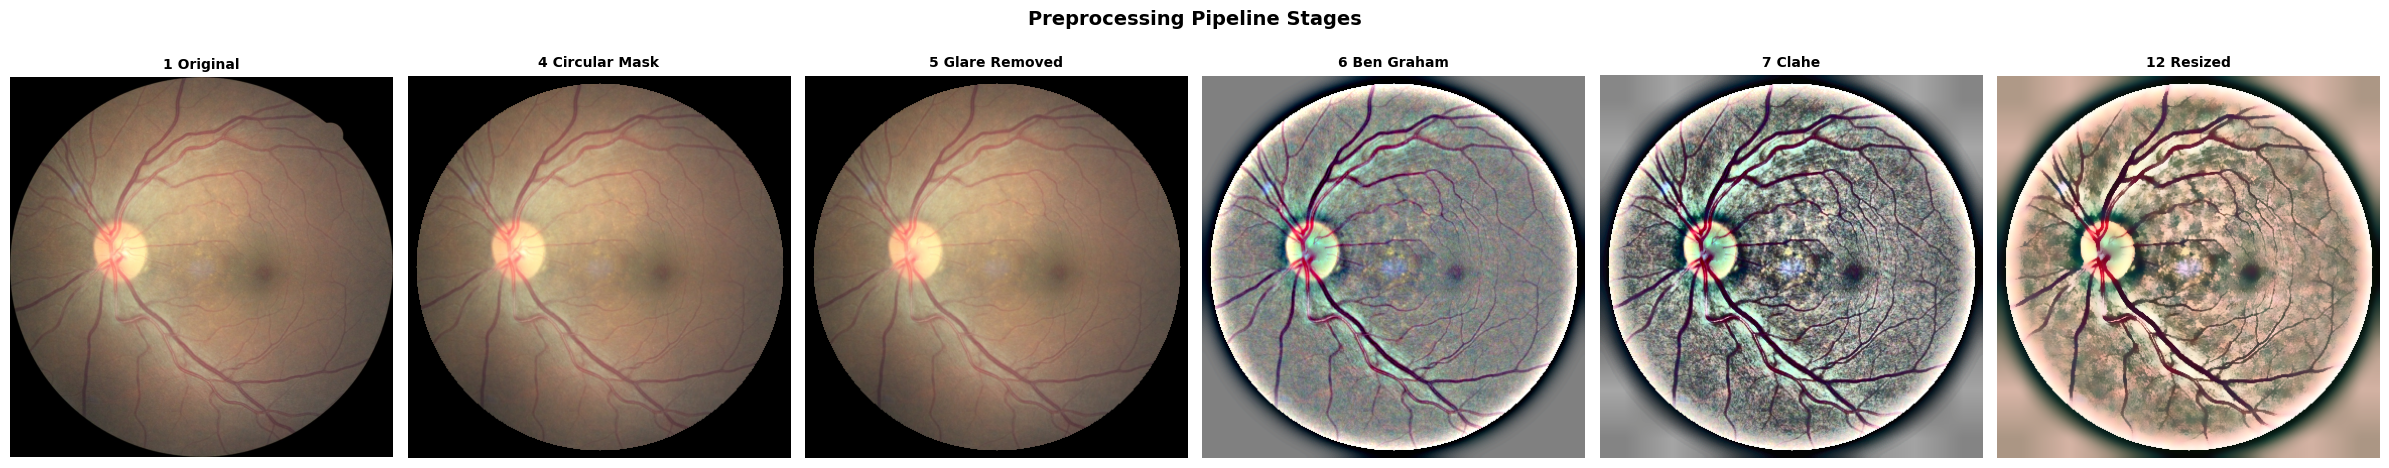

📊 Total images: 35,126

  DR Class Distribution
  Grade 0 | No DR              | 25,810 ( 73.5%) ████████████████████████████████████
  Grade 1 | Mild               |  2,443 (  7.0%) ███
  Grade 2 | Moderate           |  5,292 ( 15.1%) ███████
  Grade 3 | Severe             |    873 (  2.5%) █
  Grade 4 | Proliferative DR   |    708 (  2.0%) █


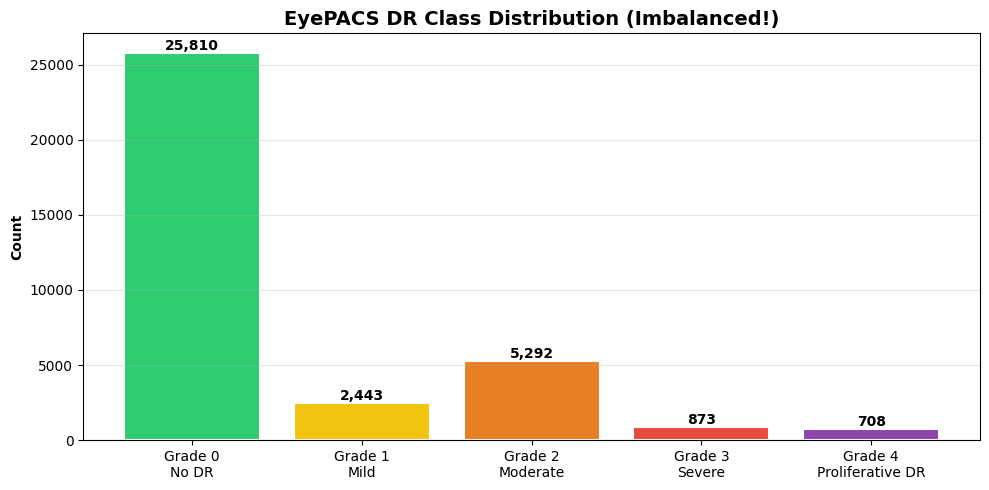

In [6]:
# ============================================================================
# CELL 5: Visualize Preprocessing Pipeline (Test on 1 image)
# ============================================================================

# Find a sample image to test (search for multiple extensions)
sample_images = []
for ext in ["**/*.jpeg", "**/*.jpg", "**/*.png"]:
    sample_images.extend(glob.glob(f"{TRAIN_IMAGES_DIR}/{ext}", recursive=True))

if sample_images:
    test_img_path = str(sorted(sample_images)[0])
    print(f"🖼️  Testing on: {Path(test_img_path).name}")
    print(f"📂 Path: {test_img_path}")

    img_uint8, stages = preprocess_image(test_img_path, apply_vessel=True, fast_denoise=True)
    tensor = normalize_for_imagenet(img_uint8)
    print(f"✅ Output tensor shape: {tensor.shape}")

    # Show key stages
    key_stages = ["1_original", "4_circular_mask", "5_glare_removed",
                  "6_ben_graham", "7_clahe", "12_resized"]
    available = [s for s in key_stages if s in stages]

    fig, axes = plt.subplots(1, len(available), figsize=(24, 5))
    for ax, key in zip(axes, available):
        ax.imshow(stages[key])
        ax.set_title(key.replace("_", " ").title(), fontsize=10, fontweight='bold')
        ax.axis('off')
    fig.suptitle("Preprocessing Pipeline Stages", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  No images found in {TRAIN_IMAGES_DIR}")
    print("   Make sure Cell 2 found the correct images folder.")

# ============================================================================
# CELL 6: Explore Dataset Distribution
# ============================================================================

df_labels = pd.read_csv(TRAIN_LABELS_CSV)
print(f"📊 Total images: {len(df_labels):,}")
print(f"\n{'='*52}")
print("  DR Class Distribution")
print(f"{'='*52}")

counts = df_labels['level'].value_counts().sort_index()
for grade, count in counts.items():
    pct = count / len(df_labels) * 100
    bar = "█" * int(pct / 2)
    name = DR_GRADE_NAMES.get(grade, f"Grade {grade}")
    print(f"  Grade {grade} | {name:<18s} | {count:>6,} ({pct:>5.1f}%) {bar}")
print(f"{'='*52}")

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
bars = ax.bar(range(NUM_CLASSES), [counts.get(i, 0) for i in range(NUM_CLASSES)],
              color=colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([f"Grade {i}\n{DR_GRADE_NAMES[i]}" for i in range(NUM_CLASSES)])
ax.set_ylabel("Count", fontweight='bold')
ax.set_title("EyePACS DR Class Distribution (Imbalanced!)", fontsize=14, fontweight='bold')
for bar, count in zip(bars, [counts.get(i, 0) for i in range(NUM_CLASSES)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================================
# CELL 7: Build EfficientNet-B4 Model
# ============================================================================

def build_efficientnet_b4(num_classes=NUM_CLASSES, pretrained=True, freeze_backbone=False):
    """Build EfficientNet-B4 with upgraded classifier head."""
    if pretrained:
        weights = models.EfficientNet_B4_Weights.IMAGENET1K_V1
        model = models.efficientnet_b4(weights=weights)
        print("✅ Loaded EfficientNet-B4 with ImageNet pretrained weights")
    else:
        model = models.efficientnet_b4(weights=None)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False
        print("🔒 Backbone frozen — only classifier head is trainable")

    # Upgraded classifier head (512-unit intermediate layer)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes),
    )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"📊 Model params: {total:,} total, {trainable:,} trainable")
    return model


# Test model build
model = build_efficientnet_b4(pretrained=True, freeze_backbone=True)
model = model.to(DEVICE)
print(f"✅ Model on {DEVICE}")

✅ Loaded EfficientNet-B4 with ImageNet pretrained weights
🔒 Backbone frozen — only classifier head is trainable
📊 Model params: 18,470,221 total, 921,605 trainable
✅ Model on cuda


In [8]:
# ============================================================================
# CELL 8: Dataset, Augmentation & Sampler
# ============================================================================

# ── Data Augmentation (DR-specific, applied on PIL images) ────────────────
train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomApply([transforms.RandomRotation(degrees=15)], p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02)
    ], p=0.3),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05))
    ], p=0.3),
])

# ── PyTorch Dataset (with disk caching, robust error handling) ────────────
CACHE_DIR = "/kaggle/working/tensor_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

class DRImageDataset(Dataset):
    """
    PyTorch Dataset with uint8 caching.
    Augmentations are applied on PIL images before normalisation.
    """

    def __init__(self, image_paths, label_map, apply_vessel=False,
                 augmentation=None, fast_denoise=True, max_retries=3):
        self.label_map = label_map
        self.apply_vessel = apply_vessel
        self.augmentation = augmentation
        self.fast_denoise = fast_denoise
        self.max_retries = max_retries
        self.min_free_gb = 2.0  # Stop caching if disk space is below 2GB

        # Filter to images that have labels
        self.valid = [p for p in image_paths if p.stem in label_map]
        if len(self.valid) < len(image_paths):
            print(f"  ⚠️ Skipped {len(image_paths) - len(self.valid)} images without labels")

    def __len__(self):
        return len(self.valid)

    def _get_free_disk_gb(self):
        stat = os.statvfs("/kaggle/working")
        return (stat.f_bavail * stat.f_frsize) / (1024**3)

    def _load_image_safe(self, path):
        """Load image with retries, return uint8 array or raise exception."""
        for attempt in range(self.max_retries):
            try:
                img_uint8, _ = preprocess_image(
                    str(path),
                    apply_vessel=self.apply_vessel,
                    fast_denoise=self.fast_denoise
                )
                return img_uint8
            except Exception as e:
                if attempt == self.max_retries - 1:
                    raise
                # Try a different random image as fallback
                path = random.choice(self.valid)
        # Should never reach here
        raise RuntimeError("Failed to load image after retries")

    def __getitem__(self, idx):
        path = self.valid[idx]
        cache_path = os.path.join(CACHE_DIR, f"{path.stem}.npy")

        try:
            # 1. Try loading from cache
            if os.path.exists(cache_path):
                img_uint8 = np.load(cache_path)
            else:
                # 2. Preprocess and save to cache if disk space permits
                img_uint8, _ = preprocess_image(
                    str(path),
                    apply_vessel=self.apply_vessel,
                    fast_denoise=self.fast_denoise
                )
                if self._get_free_disk_gb() > self.min_free_gb:
                    np.save(cache_path, img_uint8)

        except Exception as e:
            # 3. If any error (corrupted file, disk full, etc.), retry with another image
            new_idx = random.randint(0, len(self.valid) - 1)
            return self.__getitem__(new_idx)

        # 4. Convert to PIL, apply augmentation, then normalise
        img_pil = Image.fromarray(img_uint8)
        if self.augmentation is not None:
            img_pil = self.augmentation(img_pil)

        tensor = normalize_transform(img_pil)   # uses global normalisation
        label = self.label_map[path.stem]

        return tensor, label

    def get_labels(self):
        return [self.label_map[p.stem] for p in self.valid]


# ── Helper functions ─────────────────────────────────────────────────────
def compute_class_weights(labels, device):
    """Inverse-frequency class weights for CrossEntropyLoss."""
    counts = Counter(labels)
    total = sum(counts.values())
    weights = [total / (NUM_CLASSES * counts.get(c, 1)) for c in range(NUM_CLASSES)]
    print(f"⚖️  Class weights: {[f'{w:.3f}' for w in weights]}")
    return torch.tensor(weights, dtype=torch.float32).to(device)


def build_weighted_sampler(labels):
    """WeightedRandomSampler to oversample minority classes."""
    counts = Counter(labels)
    class_weights = {c: 1.0 / counts.get(c, 1) for c in range(NUM_CLASSES)}
    sample_weights = [class_weights[label] for label in labels]
    return WeightedRandomSampler(sample_weights, num_samples=len(labels), replacement=True)


print("✅ Dataset, augmentation, and sampler ready!")

✅ Dataset, augmentation, and sampler ready!


In [9]:
# ============================================================================
# CELL 9: Training Configuration
# ============================================================================
# ┌─────────────────────────────────────────────────────────────────────┐
# │  ⚠️  ADJUST THESE HYPERPARAMETERS AS NEEDED                       │
# └─────────────────────────────────────────────────────────────────────┘

# Training hyperparameters
EPOCHS            = 30        # Total training epochs
BATCH_SIZE        = 16        # Reduce to 8 if GPU OOM
LEARNING_RATE     = 1e-4      # Peak LR (after warm-up)
WARMUP_EPOCHS     = 2         # Linear LR warm-up
LABEL_SMOOTHING   = 0.1       # Reduces overconfidence
GRAD_CLIP         = 1.0       # Max gradient norm
VAL_SPLIT         = 0.2       # 20% for validation
FREEZE_BACKBONE   = True      # True for Phase 1 (transfer learning)
APPLY_VESSEL      = False     # Set True for better accuracy (slower)
FAST_DENOISE      = True      # True for faster batch processing

print(f"""
{'='*55}
  TRAINING CONFIGURATION
{'='*55}
  Epochs:           {EPOCHS}
  Batch Size:       {BATCH_SIZE}
  Learning Rate:    {LEARNING_RATE}
  Warm-up Epochs:   {WARMUP_EPOCHS}
  Label Smoothing:  {LABEL_SMOOTHING}
  Grad Clip:        {GRAD_CLIP}
  Val Split:        {VAL_SPLIT}
  Freeze Backbone:  {FREEZE_BACKBONE}
  Vessel Enhance:   {APPLY_VESSEL}
  Fast Denoise:     {FAST_DENOISE}
  Device:           {DEVICE}
{'='*55}
""")


  TRAINING CONFIGURATION
  Epochs:           30
  Batch Size:       16
  Learning Rate:    0.0001
  Warm-up Epochs:   2
  Label Smoothing:  0.1
  Grad Clip:        1.0
  Val Split:        0.2
  Freeze Backbone:  True
  Vessel Enhance:   False
  Fast Denoise:     True
  Device:           cuda



📂 Found 35,126 images in /kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15
📋 Loaded 35,126 labels
📊 Split: 28,100 train, 7,026 val


TypeError: DRImageDataset() takes no arguments

In [ ]:
# ============================================================================
# CELL 10: Train the Model 🏋️ (with stratified split + mixed precision)
# ============================================================================
from sklearn.model_selection import train_test_split

# ── Prepare data ──────────────────────────────────────────────────────────
SUPPORTED_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.tiff', '.bmp')
all_paths = sorted([
    p for p in Path(TRAIN_IMAGES_DIR).iterdir()
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
])
print(f"📂 Found {len(all_paths):,} images in {TRAIN_IMAGES_DIR}")

# Build label map from CSV
label_map = dict(zip(df_labels['image'].astype(str), df_labels['level'].astype(int)))
print(f"📋 Loaded {len(label_map):,} labels")

# Filter paths that have labels
filtered_paths = [p for p in all_paths if p.stem in label_map]
filtered_labels = [label_map[p.stem] for p in filtered_paths]

# Stratified train/val split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    filtered_paths, filtered_labels,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=filtered_labels
)
print(f"📊 Split: {len(train_paths):,} train, {len(val_paths):,} val")

# Create datasets
train_ds = DRImageDataset(train_paths, label_map, APPLY_VESSEL, train_augmentation, FAST_DENOISE)
val_ds = DRImageDataset(val_paths, label_map, APPLY_VESSEL, None, FAST_DENOISE)

# Weighted sampler (only for train)
sampler = build_weighted_sampler(train_labels)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

# ── Build model ───────────────────────────────────────────────────────────
model = build_efficientnet_b4(pretrained=True, freeze_backbone=FREEZE_BACKBONE)
model = model.to(DEVICE)

# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────
class_weights = compute_class_weights(train_labels, DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=1e-4
)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Mixed Precision Scaler (new torch.amp API) ────────────────────────────
scaler = torch.amp.GradScaler('cuda')
# ── Training Loop ─────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
best_model_path = f"{OUTPUT_DIR}/best_model.pth"

print(f"\n🚀 Starting training for {EPOCHS} epochs with mixed precision...\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]", leave=True)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        # Mixed precision forward pass (new API)
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()

        # Gradient clipping (if enabled)
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)  # Unscale gradients before clipping
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        # Optimizer step with scaler
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/max(total,1):.4f}")

    train_loss = running_loss / max(total, 1)
    train_acc = correct / max(total, 1)

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        vbar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]", leave=False)
        for inputs, labels in vbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            # No need for autocast during validation (faster without it)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)

    scheduler.step()
    dt = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch {epoch:>3d}/{EPOCHS} │ "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} │ "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} │ "
        f"LR: {current_lr:.6f} │ {dt:.1f}s"
    )

    # Save best model
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  💾 Best model saved! (Val Acc: {val_acc:.4f})")

# Save final model
final_model_path = f"{OUTPUT_DIR}/final_model.pth"
torch.save(model.state_dict(), final_model_path)
print(f"\n{'='*55}")
print(f"  ✅ Training complete!")
print(f"  🏆 Best validation accuracy: {best_val_acc:.4f}")
print(f"  💾 Best model: {best_model_path}")
print(f"  💾 Final model: {final_model_path}")
print(f"{'='*55}")

📂 Found 35,126 images in /kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15
📋 Loaded 35,126 labels
📊 Split: 28,100 train, 7,026 val
✅ Loaded EfficientNet-B4 with ImageNet pretrained weights
🔒 Backbone frozen — only classifier head is trainable
📊 Model params: 18,470,221 total, 921,605 trainable
⚖️  Class weights: ['0.272', '2.876', '1.327', '8.052', '9.929']

🚀 Starting training for 30 epochs with mixed precision...



Epoch 1/30 [train]: 100%|██████████| 1757/1757 [10:26<00:00,  2.80it/s, acc=0.3364, loss=0.6829]


Epoch   1/30 │ Train Loss: 1.0868  Acc: 0.3364 │ Val Loss: 2.6317  Acc: 0.0713 │ LR: 0.000050 │ 985.6s
  💾 Best model saved! (Val Acc: 0.0713)


Epoch 2/30 [train]: 100%|██████████| 1757/1757 [06:24<00:00,  4.57it/s, acc=0.3715, loss=0.9495]


Epoch   2/30 │ Train Loss: 1.0138  Acc: 0.3715 │ Val Loss: 2.6035  Acc: 0.0826 │ LR: 0.000100 │ 423.9s
  💾 Best model saved! (Val Acc: 0.0826)


...

Epoch  28/30 │ Train Loss: 0.8465  Acc: 0.4516 │ Val Loss: 2.6375  Acc: 0.0788 │ LR: 0.000003 │ 213.7s


Epoch 29/30 [train]: 100%|██████████| 1757/1757 [02:53<00:00, 10.11it/s, acc=0.4482, loss=1.9728]


Epoch  29/30 │ Train Loss: 0.8509  Acc: 0.4482 │ Val Loss: 2.6433  Acc: 0.0756 │ LR: 0.000001 │ 213.4s


Epoch 30/30 [train]: 100%|██████████| 1757/1757 [02:54<00:00, 10.10it/s, acc=0.4477, loss=0.5467]


Epoch  30/30 │ Train Loss: 0.8515  Acc: 0.4477 │ Val Loss: 2.6229  Acc: 0.0854 │ LR: 0.000000 │ 213.6s
  💾 Best model saved! (Val Acc: 0.0854)

  ✅ Training complete!
  🏆 Best validation accuracy: 0.0854
  💾 Best model: /kaggle/working/outputs/best_model.pth
  💾 Final model: /kaggle/working/outputs/final_model.pth


In [15]:
# ============================================================================
# CELL: Resume Training from Saved Model (Phase 2 - Full Fine-tuning with Focal Loss)
# ============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score

# ── Focal Loss Implementation ──────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        alpha: class weights (tensor). Can be None or a tensor of shape (num_classes).
        gamma: focusing parameter.
        reduction: 'mean' or 'sum'.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        inputs: raw logits (shape: N x C)
        targets: ground truth labels (shape: N)
        """
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')  # shape: N
        pt = torch.exp(-ce_loss)  # probability of true class
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            # alpha_t = alpha[targets]
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ── Load the previously saved model ────────────────────────────────────────
checkpoint_path = "/kaggle/working/outputs/best_model.pth"  # or final_model.pth
model = build_efficientnet_b4(pretrained=False, freeze_backbone=False)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model = model.to(DEVICE)

# ── Ensure all layers are trainable ────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = True

# ── Class weights for focal loss (optional, but recommended) ───────────────
# Recompute from train_labels (still in memory)
if 'train_labels' not in globals():
    # Fallback: compute from the dataset if needed (should exist)
    train_labels = train_ds.get_labels()  # if train_ds still exists
class_weights = compute_class_weights(train_labels, DEVICE)  # returns tensor on DEVICE

# ── Focal Loss criterion (instead of weighted CE) ──────────────────────────
criterion = FocalLoss(alpha=class_weights, gamma=2.0, reduction='mean')
print("✅ Using Focal Loss with gamma=2.0 and class weights")

# ── New training hyperparameters for fine-tuning ───────────────────────────
PHASE2_EPOCHS = 20          # Number of additional epochs
PHASE2_LR = 1e-5            # Lower learning rate for fine-tuning
PHASE2_WARMUP = 2           # Optional warmup epochs

# ── New optimizer (all parameters now trainable) ───────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=PHASE2_LR, weight_decay=1e-4)

# ── Cosine decay scheduler (with optional warmup) ──────────────────────────
def lr_lambda(epoch):
    if epoch < PHASE2_WARMUP:
        return (epoch + 1) / PHASE2_WARMUP
    progress = (epoch - PHASE2_WARMUP) / max(1, PHASE2_EPOCHS - PHASE2_WARMUP)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ── Mixed precision scaler ─────────────────────────────────────────────────
scaler = torch.amp.GradScaler('cuda')

# ── Continue tracking history (optional) ───────────────────────────────────
history_phase2 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_kappa": [], "lr": []}
best_val_kappa = -1.0   # Track best kappa for this phase

print(f"\n🚀 Resuming fine‑tuning from {checkpoint_path} for {PHASE2_EPOCHS} epochs with Focal Loss...\n")

for epoch in range(1, PHASE2_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Phase2 Epoch {epoch}/{PHASE2_EPOCHS} [train]", leave=True)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/max(total,1):.4f}")
    train_loss = running_loss / max(total, 1)
    train_acc = correct / max(total, 1)

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        vbar = tqdm(val_loader, desc=f"Phase2 Epoch {epoch}/{PHASE2_EPOCHS} [val]", leave=False)
        for inputs, labels in vbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss = val_loss_sum / max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)
    val_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')

    scheduler.step()
    dt = time.time() - t0

    history_phase2["train_loss"].append(train_loss)
    history_phase2["train_acc"].append(train_acc)
    history_phase2["val_loss"].append(val_loss)
    history_phase2["val_acc"].append(val_acc)
    history_phase2["val_kappa"].append(val_kappa)
    history_phase2["lr"].append(current_lr)

    print(
        f"Phase2 Epoch {epoch:>3d}/{PHASE2_EPOCHS} │ "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} │ "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  Kappa: {val_kappa:.4f} │ "
        f"LR: {current_lr:.6f} │ {dt:.1f}s"
    )

    # Save best model for this phase (based on kappa)
    if val_kappa > best_val_kappa:
        best_val_kappa = val_kappa
        torch.save(model.state_dict(), "/kaggle/working/outputs/best_model_phase2.pth")
        print(f"  💾 New best model saved! (Kappa: {val_kappa:.4f})")

print(f"\n✅ Phase 2 complete. Best kappa: {best_val_kappa:.4f}")

RuntimeError: Error(s) in loading state_dict for EfficientNet:
	Unexpected key(s) in state_dict: "classifier.2.weight", "classifier.2.bias", "classifier.2.running_mean", "classifier.2.running_var", "classifier.2.num_batches_tracked", "classifier.5.weight", "classifier.5.bias". 
	size mismatch for classifier.1.weight: copying a param with shape torch.Size([512, 1792]) from checkpoint, the shape in current model is torch.Size([5, 1792]).
	size mismatch for classifier.1.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([5]).

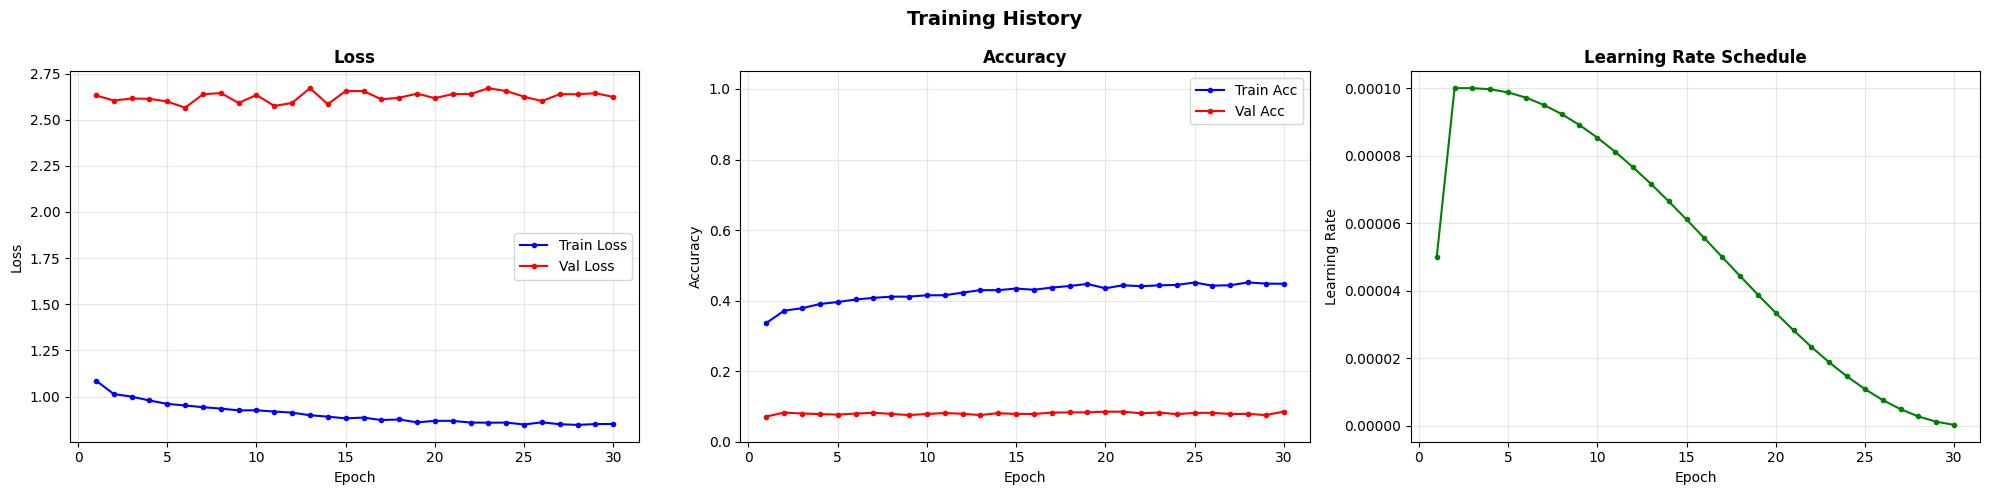

In [35]:
# ============================================================================
# CELL 11: Plot Training History
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history["train_loss"], 'b-o', label='Train Loss', markersize=3)
axes[0].plot(epochs_range, history["val_loss"], 'r-o', label='Val Loss', markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss", fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history["train_acc"], 'b-o', label='Train Acc', markersize=3)
axes[1].plot(epochs_range, history["val_acc"], 'r-o', label='Val Acc', markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy", fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

# LR
axes[2].plot(epochs_range, history["lr"], 'g-o', markersize=3)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule", fontweight='bold')
axes[2].grid(alpha=0.3)

fig.suptitle("Training History", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_history.png", dpi=150, bbox_inches='tight')
plt.show()

📊 Model params: 18,470,221 total, 18,470,221 trainable
🔍 Running predictions on validation set...


Evaluating: 100%|██████████| 440/440 [00:39<00:00, 11.19it/s]



  EVALUATION RESULTS
  Overall Accuracy     : 0.0854  (8.5%)
  Quadratic Kappa (κ)  : 0.1865
------------------------------------------------------------
  Classification Report:
                  precision    recall  f1-score   support

           No DR       0.00      0.00      0.00      5162
            Mild       0.08      0.76      0.15       489
        Moderate       0.40      0.00      0.00      1058
          Severe       0.08      0.69      0.15       175
Proliferative DR       0.10      0.75      0.18       142

        accuracy                           0.09      7026
       macro avg       0.13      0.44      0.10      7026
    weighted avg       0.07      0.09      0.02      7026



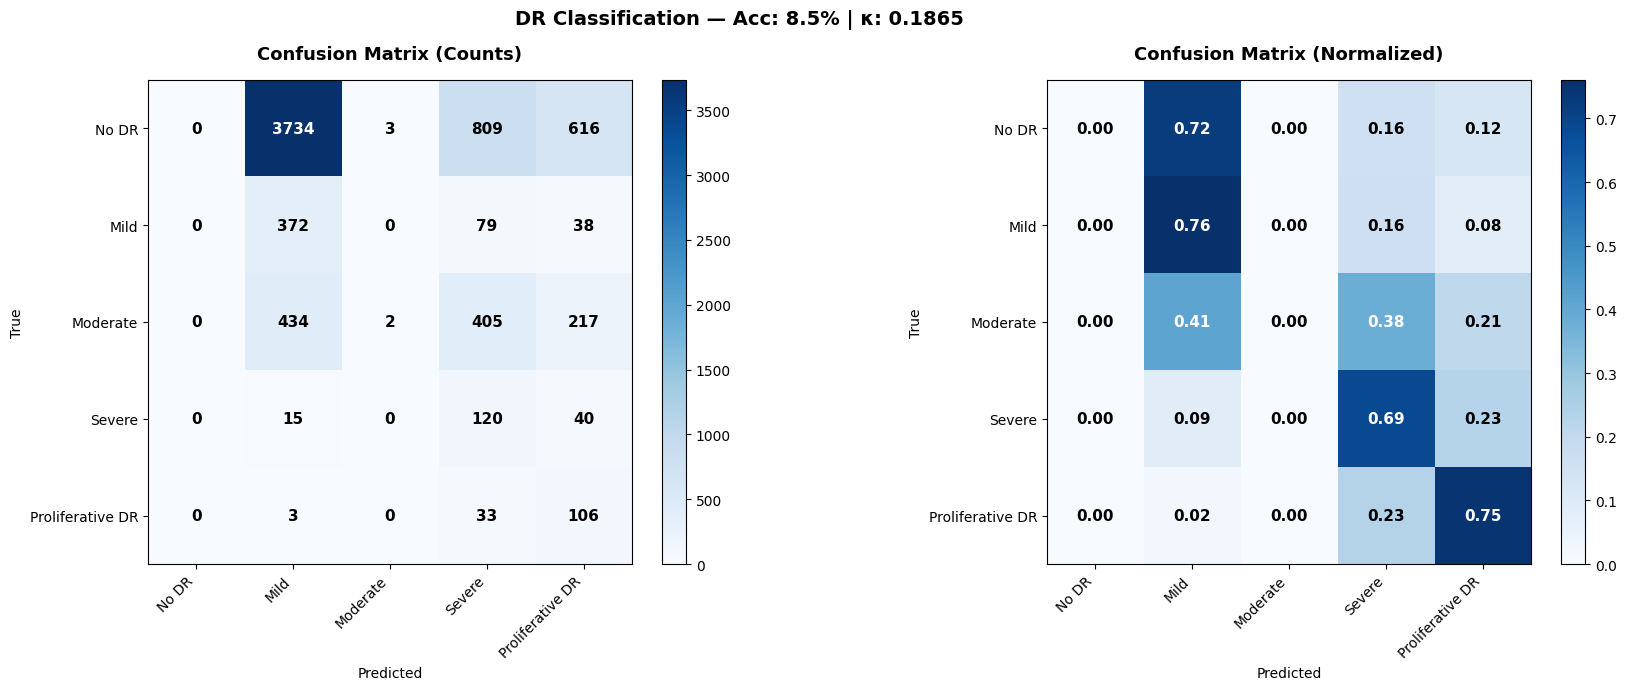


📊 Confusion matrix saved to: /kaggle/working/outputs/confusion_matrix.png


In [31]:
# ============================================================================
# CELL 12: Evaluation — Confusion Matrix & Classification Report
# ============================================================================

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    cohen_kappa_score
)

# Load best model
model_eval = build_efficientnet_b4(pretrained=False, freeze_backbone=False)
model_eval.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model_eval = model_eval.to(DEVICE)
model_eval.eval()

# Predict on validation set
print("🔍 Running predictions on validation set...")
y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Evaluating"):
        inputs = inputs.to(DEVICE)
        outputs = model_eval(inputs)
        _, preds = outputs.max(1)
        y_true.extend(labels.cpu().tolist())
        y_pred.extend(preds.cpu().tolist())

# ── Metrics ───────────────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)
kappa = cohen_kappa_score(y_true, y_pred, weights="quadratic")
class_names = [DR_GRADE_NAMES[i] for i in range(NUM_CLASSES)]

print(f"\n{'='*60}")
print(f"  EVALUATION RESULTS")
print(f"{'='*60}")
print(f"  Overall Accuracy     : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Quadratic Kappa (κ)  : {kappa:.4f}")
print(f"-"*60)
print("  Classification Report:")
print(classification_report(y_true, y_pred, labels=list(range(5)),
                            target_names=class_names, zero_division=0))
print(f"{'='*60}")

# ── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=list(range(5)))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, (normalize, title, fmt) in enumerate([
    (False, "Confusion Matrix (Counts)", "d"),
    (True, "Confusion Matrix (Normalized)", ".2f"),
]):
    ax = axes[ax_idx]
    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_display = cm.astype(float) / row_sums
    else:
        cm_display = cm

    im = ax.imshow(cm_display, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=np.arange(5), yticks=np.arange(5),
           xticklabels=class_names, yticklabels=class_names,
           xlabel='Predicted', ylabel='True')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    thresh = cm_display.max() / 2.0
    for i in range(5):
        for j in range(5):
            val = cm_display[i, j]
            text = f"{val:{fmt}}" if isinstance(val, (int, np.integer)) else f"{val:.2f}"
            ax.text(j, i, text, ha='center', va='center', fontsize=11,
                    fontweight='bold', color='white' if val > thresh else 'black')

plt.suptitle(f"DR Classification — Acc: {acc*100:.1f}% | κ: {kappa:.4f}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Confusion matrix saved to: {OUTPUT_DIR}/confusion_matrix.png")

In [ ]:
# ============================================================================
# CELL 13: Phase 2 — Unfreeze Backbone & Fine-tune
# ============================================================================
print("🔓 Phase 2: Unfreezing backbone for full fine-tuning...")

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Recompute number of trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"📊 Model params: {total:,} total, {trainable:,} trainable (all layers now trainable)")

# Lower learning rate for fine-tuning
PHASE2_EPOCHS = 15
PHASE2_LR = 1e-5

optimizer2 = torch.optim.AdamW(model.parameters(), lr=PHASE2_LR, weight_decay=1e-4)

def lr_lambda2(epoch):
    progress = epoch / max(1, PHASE2_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler2 = torch.optim.lr_scheduler.LambdaLR(optimizer2, lr_lambda2)

# New scaler for Phase 2 (optional, but keep for consistency)
scaler2 = torch.amp.GradScaler('cuda')

print(f"🚀 Starting Phase 2 for {PHASE2_EPOCHS} epochs with LR={PHASE2_LR}...")

# Continue training loop (use same history dict to extend plots)
for epoch in range(1, PHASE2_EPOCHS + 1):
    t0 = time.time()
    current_lr = optimizer2.param_groups[0]["lr"]

    # ── Train ─────────────────────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Phase2 Epoch {epoch}/{PHASE2_EPOCHS} [train]", leave=True)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer2.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler2.scale(loss).backward()

        if GRAD_CLIP > 0:
            scaler2.unscale_(optimizer2)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        scaler2.step(optimizer2)
        scaler2.update()

        running_loss += loss.item() * inputs.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct/max(total,1):.4f}")

    train_loss = running_loss / max(total, 1)
    train_acc = correct / max(total, 1)

    # ── Validate ──────────────────────────────────────────────────────────
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        vbar = tqdm(val_loader, desc=f"Phase2 Epoch {epoch}/{PHASE2_EPOCHS} [val]", leave=False)
        for inputs, labels in vbar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss_sum += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)

    scheduler2.step()
    dt = time.time() - t0

    # Append to existing history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Phase2 Epoch {epoch:>3d}/{PHASE2_EPOCHS} │ "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} │ "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} │ "
        f"LR: {current_lr:.6f} │ {dt:.1f}s"
    )

    # Save best model (overall best so far)
    if val_acc >= best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"  💾 New best model saved! (Val Acc: {val_acc:.4f})")

# Save final Phase 2 model
phase2_model_path = f"{OUTPUT_DIR}/phase2_model.pth"
torch.save(model.state_dict(), phase2_model_path)
print(f"\n✅ Phase 2 complete. Best val acc: {best_val_acc:.4f}")

In [ ]:
# ============================================================================
# CELL 14: Download Trained Model
# ============================================================================
# On Kaggle, files in /kaggle/working/ are saved as notebook Output.
# You can download them from the Output tab, OR use this cell:

import shutil

# Copy models to /kaggle/working/ root (easier to find in Output tab)
shutil.copy2(best_model_path, "/kaggle/working/best_model.pth")
shutil.copy2(final_model_path, "/kaggle/working/final_model.pth")

print(f"""
{'='*60}
  📁 ALL OUTPUT FILES (saved to Kaggle Output)
{'='*60}
  Best model:        /kaggle/working/best_model.pth
  Final model:       /kaggle/working/final_model.pth
  Training history:  {OUTPUT_DIR}/training_history.png
  Confusion matrix:  {OUTPUT_DIR}/confusion_matrix.png
{'='*60}

  🔽 HOW TO DOWNLOAD YOUR MODEL:
  1. After notebook finishes, click the "Output" tab on the right
  2. You'll see best_model.pth and final_model.pth listed
  3. Click the "⋮" menu → Download

  💡 Next steps:
  1. Check the confusion matrix — do all 5 classes have predictions?
  2. If Grade 3/4 recall is low, run Phase 2 (Cell 15)
  3. Try APPLY_VESSEL = True for better accuracy (slower training)
""")

In [ ]:
# ============================================================================
# CELL 15: Test on EyePACS Test Set (Generate Submission)
# ============================================================================
# This cell predicts on the official EyePACS test images and creates a
# submission CSV (same format as the Kaggle competition).
#
# Make sure you added the test data:
#   + Add Data → Competition Data → Diabetic Retinopathy Detection
# The test images will be at: /kaggle/input/diabetic-retinopathy-detection/test/

TEST_IMAGES_DIR = f"{KAGGLE_INPUT}/test"
test_paths = sorted(Path(TEST_IMAGES_DIR).glob("*.jpeg"))
print(f"🔍 Found {len(test_paths):,} test images")

if len(test_paths) > 0:
    # Load best model
    model_test = build_efficientnet_b4(pretrained=False, freeze_backbone=False)
    model_test.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
    model_test = model_test.to(DEVICE)
    model_test.eval()

    test_results = []

    print("🧪 Running predictions on test set...")
    for i, img_path in enumerate(tqdm(test_paths, desc="Testing")):
        try:
            img_uint8, _ = preprocess_image(str(img_path), apply_vessel=APPLY_VESSEL,
                                           fast_denoise=True)
            tensor = normalize_for_imagenet(img_uint8)
            input_tensor = tensor.unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                outputs = model_test(input_tensor)
                probabilities = torch.softmax(outputs, dim=1)
                predicted_grade = outputs.argmax(dim=1).item()
                confidence = probabilities[0, predicted_grade].item()

            test_results.append({
                "image": img_path.stem,
                "level": predicted_grade,
                "confidence": confidence,
            })
        except Exception as e:
            test_results.append({"image": img_path.stem, "level": 0, "confidence": 0.0})

    # Create submission CSV
    submission_df = pd.DataFrame(test_results)
    submission_path = f"{OUTPUT_DIR}/submission.csv"
    submission_df[["image", "level"]].to_csv(submission_path, index=False)
    shutil.copy2(submission_path, "/kaggle/working/submission.csv")

    print(f"\n✅ Submission saved: /kaggle/working/submission.csv")
    print(f"📊 Prediction distribution:")
    for grade in range(NUM_CLASSES):
        count = (submission_df["level"] == grade).sum()
        pct = count / len(submission_df) * 100
        print(f"   Grade {grade} ({DR_GRADE_NAMES[grade]:<18s}): {count:>5,} ({pct:.1f}%)")

    # Show sample predictions
    print(f"\n📋 Sample predictions (first 10):")
    print(submission_df.head(10).to_string(index=False))
else:
    print("⚠️  No test images found. Add test data from the competition.")

In [ ]:
# ============================================================================
# CELL 16: Test on a Single Image (Interactive)
# ============================================================================
# ... (update to use the new normalisation) ...
def predict_single_image(image_path, model_path=None):
    """
    Predict DR grade for a single retinal image.
    """
    if model_path is None:
        model_path = best_model_path

    # Load model
    model = build_efficientnet_b4(pretrained=False, freeze_backbone=False)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
    model = model.to(DEVICE)
    model.eval()

    # Preprocess (uint8)
    img_uint8, stages = preprocess_image(str(image_path), apply_vessel=True, fast_denoise=True)
    # Convert to PIL and normalise (no augmentation)
    img_pil = Image.fromarray(img_uint8)
    tensor = normalize_transform(img_pil).unsqueeze(0).to(DEVICE)

    # Predict
    with torch.no_grad():
        outputs = model(tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_grade = outputs.argmax(dim=1).item()

    # Display results (same as before)
    # ... (plotting code unchanged) ...
    return predicted_grade, probabilities.cpu().numpy()

In [ ]:
# ── Example: Test on a sample image ──────────────────────────────────────
# Uncomment one of these to test:

# Option 1: Test on a training image
# grade, probs = predict_single_image(f"{TRAIN_IMAGES_DIR}/10_left.jpeg")

# Option 2: Test on a test image
# grade, probs = predict_single_image(f"{TEST_IMAGES_DIR}/44353_right.jpeg")

print("✅ predict_single_image() function ready!")
print("   Usage: grade, probs = predict_single_image('path/to/image.jpeg')")

In [14]:
print("Train label distribution:", Counter(train_labels))

Train label distribution: Counter({0: 20648, 2: 4234, 1: 1954, 3: 698, 4: 566})


In [ ]:
# -*- coding: utf-8 -*-
"""
Improved Diabetic Retinopathy Detection – EyePACS Dataset
EfficientNet‑B4 | Class‑balanced training | Quadratic Weighted Kappa
"""

# ============================================================================
# CELL 1: Setup – GPU, Dependencies, Reproducibility
# ============================================================================
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import torchvision.transforms.functional as TF
import sklearn.metrics
from sklearn.model_selection import StratifiedShuffleSplit
import efficientnet_pytorch as effnet
from torchmetrics import CohenKappa

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Install extra packages if needed (Kaggle already has most)
# !pip install -q efficientnet-pytorch torchmetrics scikit-image

# ============================================================================
# CELL 2: Paths & Dataset Discovery (unchanged from original)
# ============================================================================
import glob
from pathlib import Path

def find_dataset_paths():
    input_root = "/kaggle/input"
    img_dir, labels_csv, count = None, None, 0
    all_imgs = []
    for ext in ["**/*.jpeg", "**/*.jpg", "**/*.png"]:
        all_imgs.extend(glob.glob(f"{input_root}/{ext}", recursive=True))
    if all_imgs:
        path_counts = {}
        for p in all_imgs:
            d = str(Path(p).parent)
            path_counts[d] = path_counts.get(d, 0) + 1
        # Prioritise 'train' folders
        train_folders = {d: c for d, c in path_counts.items() if "train" in d.lower()}
        if train_folders:
            img_dir = max(train_folders, key=train_folders.get)
            count = train_folders[img_dir]
        else:
            img_dir = max(path_counts, key=path_counts.get)
            count = path_counts[img_dir]
        # Find CSV
        all_csvs = glob.glob(f"{input_root}/**/*.csv", recursive=True)
        best_csv = None
        for csv_path in all_csvs:
            name = os.path.basename(csv_path).lower()
            if "trainlabels" in name and "15" in name:
                best_csv = csv_path
                break
            elif "trainlabels" in name:
                best_csv = csv_path
        if not best_csv and all_csvs:
            best_csv = all_csvs[0]
        labels_csv = best_csv
    return img_dir, labels_csv, count

print("🔍 Searching for images and labels...")
TRAIN_IMAGES_DIR, TRAIN_LABELS_CSV, IMG_COUNT = find_dataset_paths()

# Manual override if needed
if not IMG_COUNT or "test" in str(TRAIN_IMAGES_DIR).lower():
    TRAIN_IMAGES_DIR = "/kaggle/input/resized-2015-2019-blindness-detection-images/resized train 15/resized train 15"
    TRAIN_LABELS_CSV = "/kaggle/input/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv"
    if os.path.exists(TRAIN_IMAGES_DIR) and os.path.exists(TRAIN_LABELS_CSV):
         IMG_COUNT = len(list(Path(TRAIN_IMAGES_DIR).glob("*.jpeg")))

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if IMG_COUNT > 0 and TRAIN_LABELS_CSV:
    print(f"✅ Found dataset: {IMG_COUNT} images in {TRAIN_IMAGES_DIR}")
    print(f"📋 Labels: {TRAIN_LABELS_CSV}")
else:
    raise FileNotFoundError("Dataset not found. Check the paths.")

# ============================================================================
# CELL 3: Load Labels & Analyse Distribution
# ============================================================================
df = pd.read_csv(TRAIN_LABELS_CSV)
print(f"\nTotal images in CSV: {len(df)}")
print("Class distribution:")
class_counts = df['level'].value_counts().sort_index()
for grade, cnt in class_counts.items():
    print(f"  Grade {grade}: {cnt:6d} ({cnt/len(df)*100:.2f}%)")

# Plot distribution
plt.figure(figsize=(10,5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('DR Class Distribution (EyePACS)')
plt.xlabel('DR Grade')
plt.ylabel('Count')
plt.xticks(ticks=range(5), labels=['0 - No DR', '1 - Mild', '2 - Moderate', '3 - Severe', '4 - PDR'])
plt.show()

# ============================================================================
# CELL 4: Preprocessing Pipeline (simplified 5‑stage)
# ============================================================================
IMG_SIZE = 380
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def crop_black_borders(img, threshold=10):
    """Remove black borders from fundus images."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25,25))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return img
    largest = max(contours, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(largest)
    margin = int(min(w,h) * 0.02)
    x = max(0, x-margin)
    y = max(0, y-margin)
    w = min(img.shape[1]-x, w+2*margin)
    h = min(img.shape[0]-y, h+2*margin)
    return img[y:y+h, x:x+w]

def preprocess_image(image_path):
    """
    Load an image, crop black borders, resize to IMG_SIZE,
    and return a uint8 RGB array.
    """
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_black_borders(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    return img

# ============================================================================
# CELL 5: Dataset Class with Augmentation
# ============================================================================
class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, preprocess=True):
        self.df = df
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.preprocess = preprocess   # whether to apply black‑border cropping & resize

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['image']}.jpeg"
        # Some images may be .jpg – handle both
        if not img_path.exists():
            img_path = self.img_dir / f"{row['image']}.jpg"
        # Load image
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.preprocess:
            image = crop_black_borders(image)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

        label = row['level']

        # Apply additional transforms (augmentation, normalization)
        if self.transform:
            image = self.transform(image)

        return image, label

# Data augmentation (only for training)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ============================================================================
# CELL 6: Train / Validation / Test Split (stratified)
# ============================================================================
# First split off a test set (15%)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_val_idx, test_idx = next(sss.split(np.zeros(len(df)), df['level']))
df_train_val = df.iloc[train_val_idx].reset_index(drop=True)
df_test      = df.iloc[test_idx].reset_index(drop=True)

# Split train into train (70% of original) and validation (15% of original)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.15/0.85, random_state=SEED)
train_idx, val_idx = next(sss2.split(np.zeros(len(df_train_val)), df_train_val['level']))
df_train = df_train_val.iloc[train_idx].reset_index(drop=True)
df_val   = df_train_val.iloc[val_idx].reset_index(drop=True)

print(f"Train size: {len(df_train)}")
print(f"Val size:   {len(df_val)}")
print(f"Test size:  {len(df_test)}")

# Create datasets
train_dataset = DRDataset(df_train, TRAIN_IMAGES_DIR, transform=train_transform, preprocess=False)
val_dataset   = DRDataset(df_val,   TRAIN_IMAGES_DIR, transform=val_transform,   preprocess=False)
test_dataset  = DRDataset(df_test,  TRAIN_IMAGES_DIR, transform=val_transform,   preprocess=False)

# ============================================================================
# CELL 7: Weighted Random Sampler for Class Imbalance
# ============================================================================
class_counts_train = df_train['level'].value_counts().sort_index().values
class_weights = 1.0 / class_counts_train
sample_weights = [class_weights[label] for label in df_train['level']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# ============================================================================
# CELL 8: Define Model, Loss, Optimizer, and Metric
# ============================================================================
def get_model():
    model = effnet.EfficientNet.from_pretrained('efficientnet-b4')
    num_ftrs = model._fc.in_features
    model._fc = nn.Linear(num_ftrs, 5)   # 5 DR grades
    return model

model = get_model().to(device)

# Weighted Cross‑Entropy Loss (using class weights)
loss_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

# Quadratic Weighted Kappa metric (from torchmetrics)
kappa_metric = CohenKappa(num_classes=5, weights='quadratic').to(device)

# ============================================================================
# CELL 9: Training Loop with Early Stopping
# ============================================================================
num_epochs = 30
best_val_kappa = 0.0
patience = 5
patience_counter = 0
best_model_path = os.path.join(OUTPUT_DIR, "best_model.pth")

train_losses = []
val_kappas = []

for epoch in range(1, num_epochs+1):
    # Training
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        pbar.set_postfix({'loss': loss.item()})
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    # Validation
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_kappa = sklearn.metrics.cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    val_kappas.append(val_kappa)

    print(f"Epoch {epoch}: Train Loss: {epoch_loss:.4f}, Val QWK: {val_kappa:.4f}")

    scheduler.step(val_kappa)

    # Early stopping & checkpoint
    if val_kappa > best_val_kappa:
        best_val_kappa = val_kappa
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print(f"  -> New best model saved! (QWK = {val_kappa:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping after {epoch} epochs.")
            break

# Load best model
model.load_state_dict(torch.load(best_model_path))

# ============================================================================
# CELL 10: Test Evaluation
# ============================================================================
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
test_kappa = sklearn.metrics.cohen_kappa_score(all_labels, all_preds, weights='quadratic')

print("\n========== Test Results ==========")
print(f"Accuracy:          {test_accuracy:.4f}")
print(f"Quadratic Kappa:   {test_kappa:.4f}")
print("==================================")

# Confusion Matrix
cm = sklearn.metrics.confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0','1','2','3','4'],
            yticklabels=['0','1','2','3','4'])
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ============================================================================
# CELL 11: Plot Training Curves
# ============================================================================
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_kappas, label='Validation QWK')
plt.xlabel('Epoch')
plt.ylabel('Quadratic Weighted Kappa')
plt.title('Validation QWK')
plt.legend()
plt.tight_layout()
plt.show()